In [1]:
metrics_filename = "metrics.json"
output_dir = "/home/s4861264/detectron2/projects/LoTSS-GRG-detect/output/"
results_dir = "/home/s4861264/detectron2/projects/LoTSS-GRG-detect/results/"

In [2]:
import json
import os

# Read line by line, every line is a json object
def read_metrics(metrics_file):
    grg_metrics = {}
    coco_metrics = {}
    total_loss = []
    with open(metrics_file, "r") as f:
        for line in f:
            # Line is a dictionary in json format
            metrics = json.loads(line)
            for key, value in metrics.items():
                if key.startswith("GRG/"):
                    if key not in grg_metrics:
                        grg_metrics[key] = []
                    grg_metrics[key].append(value)
                elif key.startswith("bbox/") or key.startswith("segm/"):
                    if key not in coco_metrics:
                        coco_metrics[key] = []
                    coco_metrics[key].append(value)
                elif key == "total_loss":
                    total_loss.append(value)
    return grg_metrics, coco_metrics, total_loss

def read_metrics_racun(metrics_file):
    b2s_metrics = {}
    b2s_mcs_metrics = {}
    b2s_scs_metrics = {}
    loss_box_reg = []
    loss_cls = []
    loss_mask = []
    total_loss = []
    with open(metrics_file, "r") as f:
        for line in f:
            # Line is a dictionary in json format
            try:
                metrics = json.loads(line)
            except json.JSONDecodeError:
                continue
            for key, value in metrics.items():
                # Metrics
                if key.startswith("B2S/"):
                    metric_name = key.split("/")[-1]

                    if metric_name not in b2s_metrics:
                        b2s_metrics[metric_name] = []
                    b2s_metrics[metric_name].append(value)

                if key.startswith("B2S_CLASSWISE/MCS_"):
                    metric_name = key.split("/MCS_")[-1]

                    if any(x in metric_name for x in ["tp", "fp", "fn"]):
                        continue  # Skip raw counts

                    if metric_name not in b2s_mcs_metrics:
                        b2s_mcs_metrics[metric_name] = []
                    b2s_mcs_metrics[metric_name].append(value)

                if key.startswith("B2S_CLASSWISE/SCS_"):
                    metric_name = key.split("/SCS_")[-1]

                    if any(x in metric_name for x in ["tp", "fp", "fn"]):
                        continue  # Skip raw counts

                    if metric_name not in b2s_scs_metrics:
                        b2s_scs_metrics[metric_name] = []
                    b2s_scs_metrics[metric_name].append(value)

                # Losses
                if key == "loss_box_reg":
                    loss_box_reg.append(value)
                elif key == "loss_cls":
                    loss_cls.append(value)
                elif key == "loss_mask":
                    loss_mask.append(value)
                elif key == "total_loss":
                    total_loss.append(value)

    return b2s_metrics, b2s_mcs_metrics, b2s_scs_metrics, loss_box_reg, loss_cls, loss_mask, total_loss

def display_b2s_metrics(metrics_file):
    metrics_file = os.path.join(output_dir, metrics_file, metrics_filename)
    import matplotlib.pyplot as plt
    b2s_metrics, b2s_mcs_metrics, b2s_scs_metrics, loss_box_reg, loss_cls, loss_mask, total_loss = read_metrics_racun(metrics_file)

    
    # Run a running average with window size 10 for better visualization of trends
    def running_average(data, window_size=40):
        if len(data) < window_size:
            return data  # Not enough data for running average
        return [sum(data[i:i+window_size])/window_size for i in range(len(data)-window_size+1)]

    total_loss = running_average(total_loss)
    loss_box_reg = running_average(loss_box_reg)
    loss_cls = running_average(loss_cls)
    loss_mask = running_average(loss_mask)

    plt.plot(total_loss, label="total_loss")
    plt.plot(loss_box_reg, label="loss_box_reg")
    plt.plot(loss_cls, label="loss_cls")
    plt.plot(loss_mask, label="loss_mask")
    plt.yscale("log")  # Use logarithmic scale for better visibility of loss trends
    plt.legend()
    plt.title("Losses")
    plt.show()

    segmentation_metrics = {k: v for k, v in b2s_metrics.items() if "segm" in k}
    bbox_metrics = {k: v for k, v in b2s_metrics.items() if "bbox" in k}

    # Plot B2S metrics for segmentation
    for key, value in segmentation_metrics.items():
        max_val = max(value)
        plt.plot(value, label=f"{key} (max={max_val:.4f})")
    plt.legend()
    plt.title("B2S Segmentation Metrics")
    plt.show()

    # Plot B2S metrics for bounding boxes
    for key, value in bbox_metrics.items():
        max_val = max(value)
        plt.plot(value, label=f"{key} (max={max_val:.4f})")
    plt.legend()
    plt.title("B2S Bounding Box Metrics")
    plt.show()

    # B2S MCS segmentation metrics
    for key, value in b2s_mcs_metrics.items():
        if "segm" in key:
            max_val = max(value)
            plt.plot(value, label=f"{key} (max={max_val:.4f})")
    plt.legend()
    plt.title("B2S MCS Segmentation Metrics")
    plt.show()

    # B2S MCS bbox metrics
    for key, value in b2s_mcs_metrics.items():
        if "bbox" in key:
            max_val = max(value)
            plt.plot(value, label=f"{key} (max={max_val:.4f})")
    plt.legend()
    plt.title("B2S MCS Bounding Box Metrics")
    plt.show()

    # B2S SCS segmentation metrics
    for key, value in b2s_scs_metrics.items():
        if "segm" in key:
            max_val = max(value)
            plt.plot(value, label=f"{key} (max={max_val:.4f})")
    plt.legend()
    plt.title("B2S SCS Segmentation Metrics")
    plt.show()

    # B2S SCS bbox metrics
    for key, value in b2s_scs_metrics.items():
        if "bbox" in key:
            max_val = max(value)
            plt.plot(value, label=f"{key} (max={max_val:.4f})")
    plt.legend()
    plt.title("B2S SCS Bounding Box Metrics")
    plt.show()

    mcs_metrics = {k: v for k, v in b2s_mcs_metrics.items() if "segm" in k or "bbox" in k}
    scs_metrics = {k: v for k, v in b2s_scs_metrics.items() if "segm" in k or "bbox" in k}
    overall_metrics = {k: v for k, v in b2s_metrics.items() if "segm" in k or "bbox" in k}
    print("Final B2S Metrics:")
    print("MCS metrics:", mcs_metrics)
    print("SCS metrics:", scs_metrics)
    print("Overall metrics:", overall_metrics)

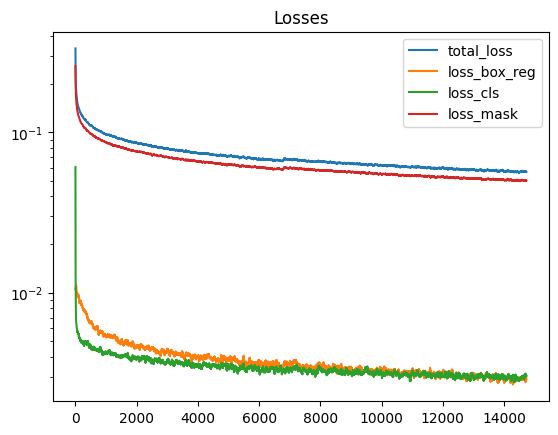

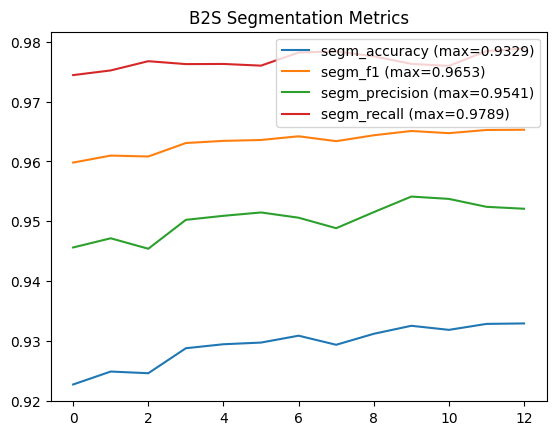

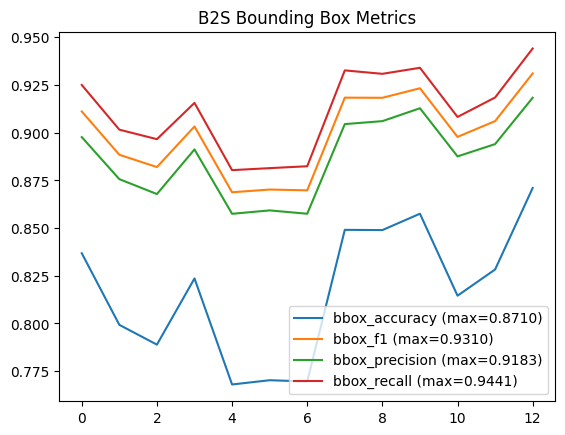

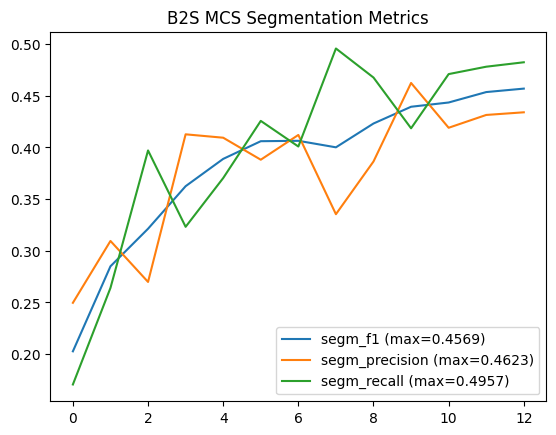

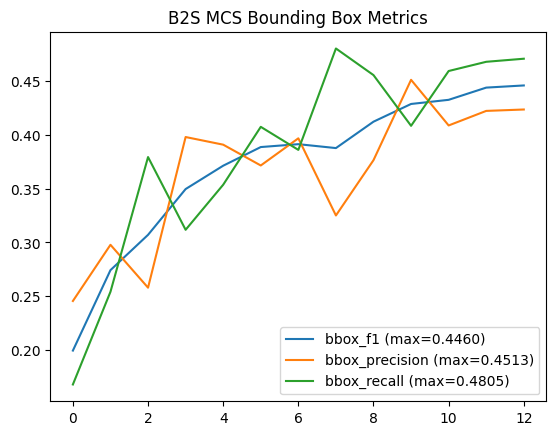

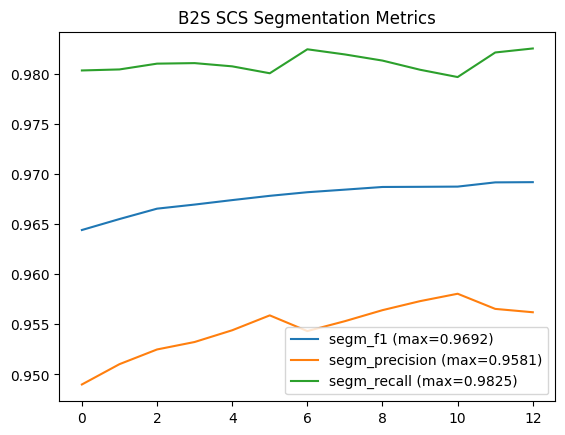

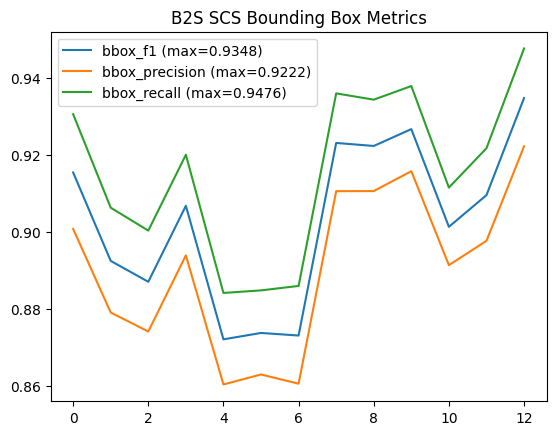

Final B2S Metrics:
MCS metrics: {'bbox_f1': [0.19932049830124574, 0.2741769547325103, 0.3070395371263259, 0.3496391339214113, 0.3713713713713714, 0.3887247101614003, 0.3913988886204397, 0.3877668782458165, 0.4123355617856373, 0.42882161621215914, 0.43267504488330344, 0.44404250508704496, 0.4460496613995485], 'bbox_precision': [0.24546722454672246, 0.2977653631284916, 0.2578555231616456, 0.39805234327449784, 0.3909378292939937, 0.37157757496740546, 0.3968642822146007, 0.32505643340857787, 0.3765261914139425, 0.45129015271195366, 0.40882103477523324, 0.42236559139784946, 0.4236706689536878], 'bbox_recall': [0.16777883698760723, 0.2540514775977121, 0.3794089609151573, 0.3117254528122021, 0.3536701620591039, 0.4075309818875119, 0.38608198284080075, 0.4804575786463298, 0.45567206863679693, 0.40848427073403243, 0.45948522402287895, 0.4680648236415634, 0.47092469018112487], 'segm_f1': [0.202718006795017, 0.28497942386831276, 0.32131147540983607, 0.3624699278267843, 0.3888888888888889, 0.40600

In [4]:
display_b2s_metrics("mask_rcnn_b2s_rgz_baseline")

In [4]:
import ast
import json
import re

import numpy as np

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_association_heatmaps(results, membership_thresholds, validity_thresholds, mcs=False):
    metrics = ["Association F1", "Association Precision", "Association Recall", "Association Jaccard"]
    if mcs:
        metrics = [f"MCS {metric}" for metric in metrics]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    best_f1 = -1
    best_f1_combo = None
    best_recall = -1
    best_recall_combo = None
    best_precision = -1
    best_precision_combo = None
    best_jaccard = -1
    best_jaccard_combo = None
    for ax, metric in zip(axes, metrics):
        # Build matrix: rows = membership threshold, cols = validity threshold
        matrix = np.zeros((len(membership_thresholds), len(validity_thresholds)))
        
        for i, m_thresh in enumerate(membership_thresholds):
            for j, v_thresh in enumerate(validity_thresholds):
                key = f"v_{v_thresh:.1f}_m_{m_thresh:.1f}"
                res = results[key].get(metric, 0.0)
                matrix[i, j] = res

                if metric == ("Association F1" if not mcs else "MCS Association F1") and res > best_f1:
                    best_f1 = res
                    best_f1_combo = (m_thresh, v_thresh)
                if metric == ("Association Precision" if not mcs else "MCS Association Precision") and res > best_precision:
                    best_precision = res
                    best_precision_combo = (m_thresh, v_thresh)
                if metric == ("Association Recall" if not mcs else "MCS Association Recall") and res > best_recall:
                    best_recall = res
                    best_recall_combo = (m_thresh, v_thresh)
                if metric == ("Association Jaccard" if not mcs else "MCS Association Jaccard") and res > best_jaccard:
                    best_jaccard = res
                    best_jaccard_combo = (m_thresh, v_thresh)
        
        sns.heatmap(
            matrix,
            ax=ax,
            vmin=0, vmax=1,
            annot=True, fmt=".2f",
            xticklabels=[f"{v:.1f}" for v in validity_thresholds],
            yticklabels=[f"{m:.1f}" for m in membership_thresholds],
            cmap="YlOrRd",
            linewidths=0.5,
        )
        ax.set_title(metric)
        ax.set_xlabel("Validity threshold")
        ax.set_ylabel("Membership threshold")
        
        # Mark the best cell
        best_idx = np.unravel_index(np.argmax(matrix), matrix.shape)
        ax.add_patch(plt.Rectangle(
            (best_idx[1], best_idx[0]), 1, 1,
            fill=False, edgecolor="blue", lw=2
        ))
    
    plt.suptitle("Association metrics across thresholds", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"Best F1: {best_f1:.4f} at Membership Threshold: {best_f1_combo[0]:.2f}, Validity Threshold: {best_f1_combo[1]:.2f}")
    print(f"Best Precision: {best_precision:.4f} at Membership Threshold: {best_precision_combo[0]:.2f}, Validity Threshold: {best_precision_combo[1]:.2f}")
    print(f"Best Recall: {best_recall:.4f} at Membership Threshold: {best_recall_combo[0]:.2f}, Validity Threshold: {best_recall_combo[1]:.2f}")
    print(f"Best Jaccard: {best_jaccard:.4f} at Membership Threshold: {best_jaccard_combo[0]:.2f}, Validity Threshold: {best_jaccard_combo[1]:.2f}")


def calculate_ap(precision, recall):
    # Ensure inputs are numpy arrays
    precision = np.array(precision)
    recall = np.array(recall)
    
    # 1. Sort by recall to ensure they are in order
    indices = np.argsort(recall)
    precision = precision[indices]
    recall = recall[indices]
    
    # 2. Calculate the change in recall (delta R) at each step
    # We prepend 0 to recall to handle the very first interval
    recall_diff = np.diff(recall, prepend=0)
    
    # 3. AP is the sum of (Precision * change in Recall)
    ap = np.sum(precision * recall_diff)
    return ap

def safe_to_dict(obj):
    """
    Convert a string representation of a dict to an actual dict.
    If obj is already a dict, return it as-is.
    If obj is a string, parse it using json.loads first (clean JSON),
    then fall back to ast.literal_eval with numpy wrapper cleanup.
    
    Handles numpy types like np.float64(...) by stripping them.
    """
    if isinstance(obj, dict):
        return obj
    if isinstance(obj, str):
        # Try direct JSON parsing first
        try:
            return json.loads(obj)
        except (json.JSONDecodeError, ValueError):
            pass
        
        # Try ast.literal_eval with numpy wrapper cleanup
        try:
            # Replace numpy type wrappers like np.float64(...) with just (...)
            # This regex matches np.TYPENAME(...) and captures the content inside
            cleaned_str = re.sub(r'np\.\w+\(([^)]+)\)', r'\1', obj)
            return ast.literal_eval(cleaned_str)
        except (ValueError, SyntaxError) as e:
            raise ValueError(f"Could not parse string to dict: {e}")
    raise TypeError(f"Expected dict or str, got {type(obj)}")

def get_results(results_file):
    with open(results_file, "r") as f:
        results_dict = json.load(f)

    membership_metrics = {}
    validity_metrics = {}
    
    # First pass: collect all threshold values
    validity_thresholds = set()
    membership_thresholds = set()
    
    for key in results_dict.keys():
        match = re.match(r"v_(\d+\.\d+)_m_(\d+\.\d+)", key)
        if match:
            validity_thresholds.add(float(match.group(1)))
            membership_thresholds.add(float(match.group(2)))
    
    # Sort for consistent ordering
    validity_thresholds = sorted(validity_thresholds)
    membership_thresholds = sorted(membership_thresholds)
    
    # Second pass: aggregate metrics
    membership_metrics = {metric: [] for metric in ["Membership Jaccard", "Membership Precision", "Membership Recall", "Membership F1"]}
    membership_metrics['threshold'] = []
    
    validity_metrics = {metric: [] for metric in ["Validity Jaccard", "Validity Precision", "Validity Recall", "Validity F1"]}
    validity_metrics['threshold'] = []
    
    # For membership metrics: collect one (validity_threshold, membership_threshold) pair per membership_threshold
    # (all have the same values, so pick the first validity_threshold)
    for m_thresh in membership_thresholds:
        key = f"v_{validity_thresholds[0]:.1f}_m_{m_thresh:.1f}"
        if key in results_dict:
            res_dict = results_dict[key]
            for metric in membership_metrics:
                if metric != 'threshold' and metric in res_dict:
                    membership_metrics[metric].append(res_dict[metric])
            membership_metrics['threshold'].append(m_thresh)
    
    # For validity metrics: collect one (validity_threshold, membership_threshold) pair per validity_threshold
    # (all have the same values, so pick the first membership_threshold)
    for v_thresh in validity_thresholds:
        key = f"v_{v_thresh:.1f}_m_{membership_thresholds[0]:.1f}"
        if key in results_dict:
            res_dict = results_dict[key]
            for metric in validity_metrics:
                if metric != 'threshold' and metric in res_dict:
                    validity_metrics[metric].append(res_dict[metric])
            validity_metrics['threshold'].append(v_thresh)
    
    return membership_metrics, validity_metrics, results_dict, membership_thresholds, validity_thresholds

def display_results(results_folder):  
    results_file = os.path.join(results_dir, results_folder, "results.json")
    (
        membership_metrics,
        validity_metrics,
        results_dict,
        membership_thresholds,
        validity_thresholds
    ) = get_results(results_file)

    membership_recall = membership_metrics.get("Membership Recall", [])
    membership_precision = membership_metrics.get("Membership Precision", [])
    validity_recall = validity_metrics.get("Validity Recall", [])
    validity_precision = validity_metrics.get("Validity Precision", [])

    membership_ap = calculate_ap(membership_precision, membership_recall)
    validity_ap = calculate_ap(validity_precision, validity_recall)

    print("Average Precision (AP) at all thresholds. It is computed as the area under the precision-recall curve:")
    print(f"Membership AP: {membership_ap:.4f}")
    print(f"Validity AP: {validity_ap:.4f}")

    # Report the best metrics from all the thresholds
    print("\nBest Metrics across all thresholds:")

    print("\nMembership Metrics:")
    for metric_name in ["Membership Jaccard", "Membership Precision", "Membership Recall", "Membership F1"]:
        metric_values = membership_metrics.get(metric_name, [])
        if metric_values:
            best_value = max(metric_values)
            print(f"Best {metric_name}: {best_value:.4f}")

    print("\nValidity Metrics:")
    for metric_name in ["Validity Jaccard", "Validity Precision", "Validity Recall", "Validity F1"]:
        metric_values = validity_metrics.get(metric_name, [])
        if metric_values:
            best_value = max(metric_values)
            print(f"Best {metric_name}: {best_value:.4f}")

    membership_x = membership_metrics.get('threshold', [])
    print("Membership Metrics across thresholds:")
    for key, value in membership_metrics.items():
        if key != 'threshold':
            plt.plot(membership_x, value, label=key)
            print(f"{key} with threshold: {membership_x} and value: {value}")
    plt.xlabel("Membership Threshold")
    plt.ylabel("Membership Metric Value")
    plt.title("Membership Metric vs Membership Threshold")
    plt.legend()
    plt.show()

    print("Validity Metrics across thresholds:")
    validity_x = membership_x #validity_metrics.get('threshold', [])
    for key, value in validity_metrics.items():
        if key != 'threshold':
            plt.plot(validity_x, value, label=key)
            print(f"{key} with threshold: {validity_x} and value: {value}")
    plt.xlabel("Validity Threshold")
    plt.ylabel("Validity Metric Value")
    plt.title("Validity Metric vs Validity Threshold")
    plt.legend()
    plt.show()

    plot_association_heatmaps(results_dict, membership_thresholds, validity_thresholds)

    plot_association_heatmaps(results_dict, membership_thresholds, validity_thresholds, mcs=True)

Average Precision (AP) at all thresholds. It is computed as the area under the precision-recall curve:
Membership AP: 0.3108
Validity AP: 0.8906

Best Metrics across all thresholds:

Membership Metrics:
Best Membership Jaccard: 0.3319
Best Membership Precision: 0.4317
Best Membership Recall: 1.0000
Best Membership F1: 0.4983

Validity Metrics:
Best Validity Jaccard: 0.8127
Best Validity Precision: 0.9330
Best Validity Recall: 1.0000
Best Validity F1: 0.8967
Membership Metrics across thresholds:
Membership Jaccard with threshold: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] and value: [0.002123998989703894, 0.16457290774530778, 0.19817635928775312, 0.22385857708626525, 0.24674244524535624, 0.2690629190173805, 0.2924680154303, 0.3158820502185251, 0.3318644808743169, 0.3003764088900167, 0.0]
Membership Precision with threshold: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] and value: [0.002123998989703894, 0.17415990635821235, 0.2122637068602433, 0.24209043383800666, 

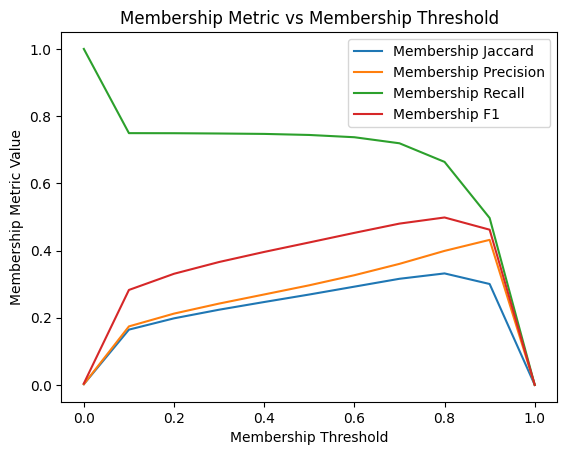

Validity Metrics across thresholds:
Validity Jaccard with threshold: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] and value: [0.017822811891779457, 0.6695418490745958, 0.6908908938814532, 0.7057249866238631, 0.7177508612760916, 0.7329568180727325, 0.7699326748914938, 0.803697491382965, 0.8126619699383795, 0.800879915151039, 0.0]
Validity Precision with threshold: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] and value: [0.017822811891779457, 0.6858221104040254, 0.7092515066476515, 0.7259104346185294, 0.7401459619341564, 0.7593442840330842, 0.8104539894956472, 0.8742982034007059, 0.9115259565488879, 0.9329611494989246, 0.0]
Validity Recall with threshold: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] and value: [1.0, 0.9657594198066022, 0.9638837945981994, 0.96209153051017, 0.9595490163387796, 0.9547349116372124, 0.9390213404468156, 0.9086987329109704, 0.8822524174724908, 0.8497832610870291, 0.0]
Validity F1 with threshold: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0

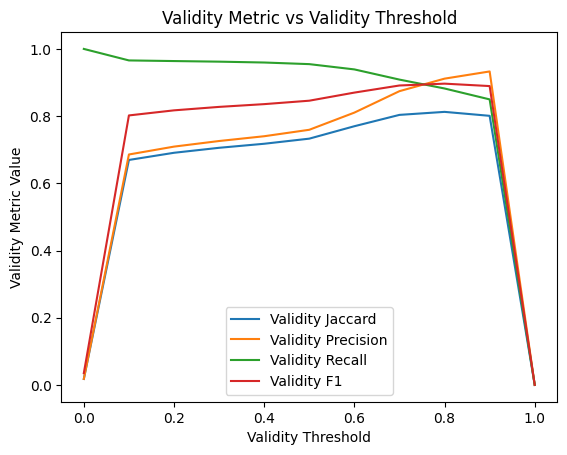

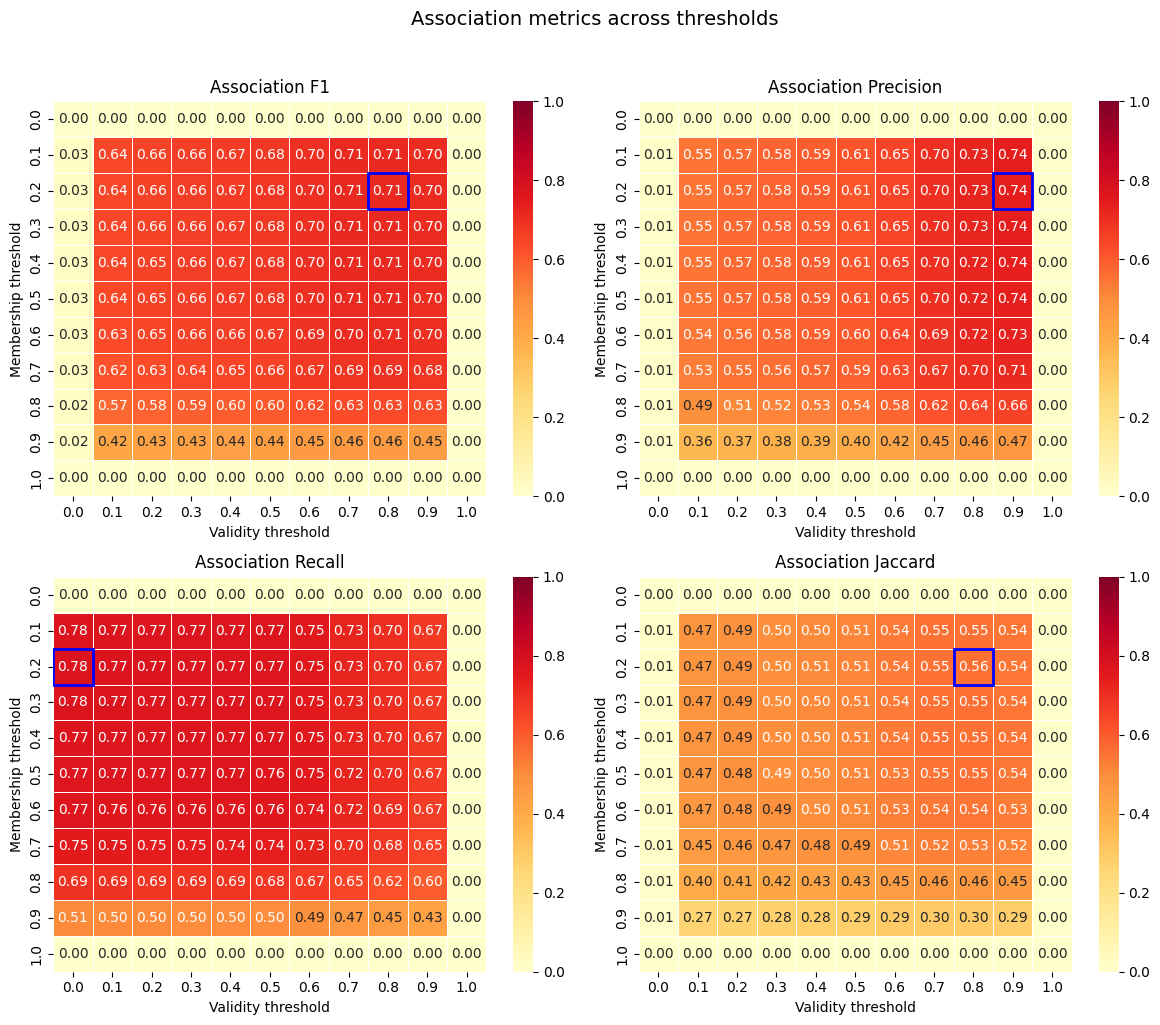

Best F1: 0.7140 at Membership Threshold: 0.20, Validity Threshold: 0.80
Best Precision: 0.7393 at Membership Threshold: 0.20, Validity Threshold: 0.90
Best Recall: 0.7760 at Membership Threshold: 0.20, Validity Threshold: 0.00
Best Jaccard: 0.5552 at Membership Threshold: 0.20, Validity Threshold: 0.80


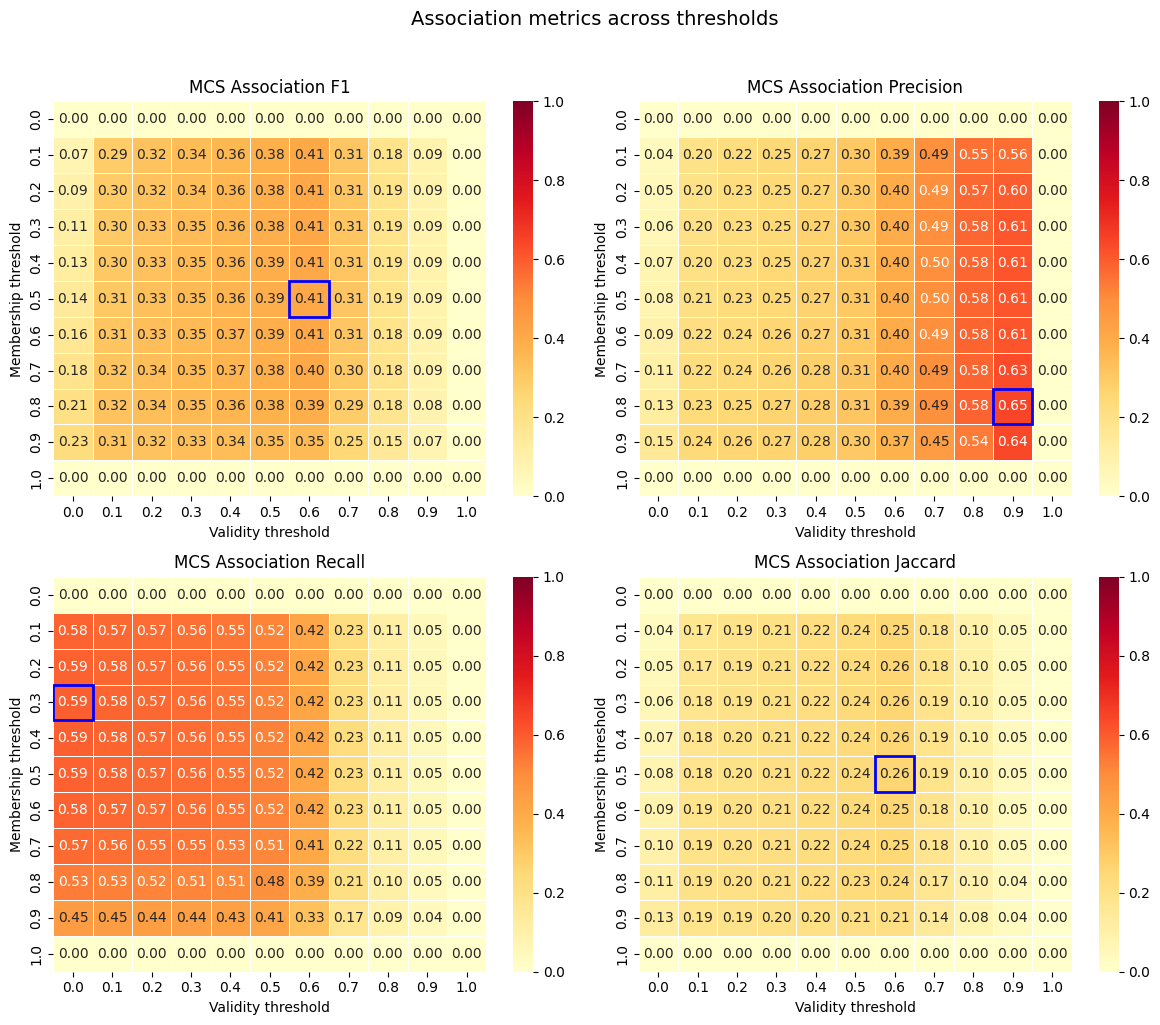

Best F1: 0.4091 at Membership Threshold: 0.50, Validity Threshold: 0.60
Best Precision: 0.6471 at Membership Threshold: 0.80, Validity Threshold: 0.90
Best Recall: 0.5900 at Membership Threshold: 0.30, Validity Threshold: 0.00
Best Jaccard: 0.2571 at Membership Threshold: 0.50, Validity Threshold: 0.60


In [11]:
display_results("racast_v8_iou")